In [ ]:
from langchain_core.messages import HumanMessage

from core.graph import create_after_sales_graph


In [ ]:
graph = create_after_sales_graph()
config = {
    "configurable": {
        "thread_id": "User_1",
    }
}

### 退款功能测试 （无 order_id 版）

In [ ]:
# for chunk in graph.stream({"messages": [HumanMessage(content="我要退款。")]},
#                           config,
#                           stream_mode="values",
#                           ):
#     print(chunk)
#     print()

### 物流信息查询功能测试

In [ ]:
for chunk in graph.stream({"messages": [HumanMessage(content="帮我查查单号 20002 的物流。")]},
                          config,
                          stream_mode="values",
                          ):
    print(chunk)
    print()

### 故障询问功能测试 （正常版）

In [ ]:
for chunk in graph.stream({"messages": [HumanMessage(content="手机在运输过程中坏了，我要退款")]},
                          config,
                          stream_mode="values",
                          ):
    print(chunk)
    print()

### vision agent 功能测试

In [ ]:
# 模拟用户发送带图片的消息
input_state = {
    "messages": [
        HumanMessage(content=[
            {"type": "text", "text": "手机在运输过程中坏了，我要退款"},
            {"type": "image_url",
             "image_url": {
                 "url": "G:\\Agent\\基于多智能体的电商售后智能路由与决策系统\\data\\phone_testdata\\project_data\\train\\cracked\\$_57.jpeg"}}
        ])
    ]
}

for chunk in graph.stream({"messages": input_state['messages']},
                          config,
                          stream_mode="values",
                          ):
    print(chunk)
    print()

In [ ]:
# from tools import rag_tools
#
# decision_info = rag_tools.get_policy_decision(
#     user_text="手机在运输过程中坏了，我要退款",
#     vision_tags=['蜘蛛网纹'],
#     purchase_date_str="2024-05-17 14:00:00",
#     category="屏幕显示",
# )

In [44]:
import json
import os

from datasets import Dataset
from langchain_community.embeddings import DashScopeEmbeddings  # 复用你之前的 embeddings
from langchain_openai import ChatOpenAI
from ragas import evaluate
from ragas.metrics import faithfulness, answer_relevancy, context_precision

from config.load_key import load_key

# 1. 环境初始化
load_key()
openAI_key = os.environ.get("OPENAI_API_KEY")
Tongyi_api_key = os.environ.get("DASHSCOPE_API_KEY")
# 读取数据
data_path = "data/eval_dataset.json"
if not os.path.exists(data_path):
    print("❌ 错误：找不到数据文件 data/eval_dataset.json")
    raise Exception('error1')

with open(data_path, "r", encoding="utf-8") as f:
    eval_data = json.load(f)

# eval_data = eval_data[:1]
# 数据格式校验与清洗
if isinstance(eval_data, list) and len(eval_data) > 0 and isinstance(eval_data[0], list):
    eval_data = eval_data[0]
valid_data = [item for item in eval_data if isinstance(item, dict)]
dataset = Dataset.from_list(valid_data)

# 2. 【核心修复】：显式配置裁判 LLM
# 重点：配置代理地址，并处理 "requested 3 generations" 的问题
judge_llm = ChatOpenAI(
    model="gpt-4o-mini",
    openai_api_key=openAI_key,
    base_url="https://api.chatanywhere.tech/v1",
    temperature=0,
)

# 3. 【核心修复】：显式配置评估用的 Embeddings
# Ragas 计算相关性时需要向量模型。如果不配置，它会默认调 OpenAI 官方接口导致 401
judge_embeddings = DashScopeEmbeddings(
    model='text-embedding-v3',
    dashscope_api_key=Tongyi_api_key  # 确保环境变量里有这个
)

print(f"🚀 准备评估 {len(valid_data)} 条数据...")
print("⚖️ 正在启动『AI 大法官』进行语义审计 (预计耗时 1-3 分钟)...")

# 4. 执行评估：显式传入 llm 和 embeddings
try:
    score_result = evaluate(
        dataset=dataset,
        metrics=[faithfulness, answer_relevancy, context_precision],
        llm=judge_llm,
        embeddings=judge_embeddings
    )
except Exception as e:
    print(f"❌ 评估过程中出现异常: {e}")
    # 如果还是报 Key 错误，打印一下环境变量看看
    # print(f"Current Key: {os.environ.get('OPENAI_API_KEY')}")
    raise Exception('error2')

import numpy as np

print("\n" + "=" * 60)
print("📊 手机售后系统 RAG 自动化评估报告")
print("-" * 60)
print(f"回答忠实度 (Faithfulness): {np.mean(score_result['faithfulness']):.4f}")
print(f"答案相关性 (Relevancy): {np.mean(score_result['answer_relevancy']):.4f}")
print(f"上下文精准度 (Context Precision): {np.mean(score_result['context_precision']):.4f}")
print("=" * 60)

C:\Users\Administrator\AppData\Local\Temp\ipykernel_23864\889803844.py:8: DeprecationWarning: Importing faithfulness from 'ragas.metrics' is deprecated and will be removed in v1.0. Please use 'ragas.metrics.collections' instead. Example: from ragas.metrics.collections import faithfulness
  from ragas.metrics import faithfulness, answer_relevancy, context_precision
C:\Users\Administrator\AppData\Local\Temp\ipykernel_23864\889803844.py:8: DeprecationWarning: Importing answer_relevancy from 'ragas.metrics' is deprecated and will be removed in v1.0. Please use 'ragas.metrics.collections' instead. Example: from ragas.metrics.collections import answer_relevancy
  from ragas.metrics import faithfulness, answer_relevancy, context_precision
C:\Users\Administrator\AppData\Local\Temp\ipykernel_23864\889803844.py:8: DeprecationWarning: Importing context_precision from 'ragas.metrics' is deprecated and will be removed in v1.0. Please use 'ragas.metrics.collections' instead. Example: from ragas.metr

🚀 准备评估 50 条数据...
⚖️ 正在启动『AI 大法官』进行语义审计 (预计耗时 1-3 分钟)...


Evaluating:   1%|          | 1/150 [00:11<27:23, 11.03s/it]LLM returned 1 generations instead of requested 3. Proceeding with 1 generations.
LLM returned 1 generations instead of requested 3. Proceeding with 1 generations.
LLM returned 1 generations instead of requested 3. Proceeding with 1 generations.
LLM returned 1 generations instead of requested 3. Proceeding with 1 generations.
LLM returned 1 generations instead of requested 3. Proceeding with 1 generations.
Evaluating:   8%|▊         | 12/150 [01:16<11:01,  4.79s/it]LLM returned 1 generations instead of requested 3. Proceeding with 1 generations.
LLM returned 1 generations instead of requested 3. Proceeding with 1 generations.
Evaluating:  17%|█▋        | 25/150 [01:43<04:37,  2.22s/it]LLM returned 1 generations instead of requested 3. Proceeding with 1 generations.
LLM returned 1 generations instead of requested 3. Proceeding with 1 generations.
Evaluating:  20%|██        | 30/150 [01:57<04:55,  2.46s/it]LLM returned 1 generati


📊 手机售后系统 RAG 自动化评估报告
------------------------------------------------------------
回答忠实度 (Faithfulness): 0.6519
答案相关性 (Relevancy): 0.6844
上下文精准度 (Context Precision): 0.9000


前10条
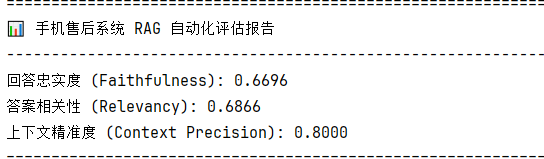

In [45]:
score_result['faithfulness'], score_result['answer_relevancy'], score_result['context_precision']

([0.8571428571428571,
  0.8333333333333334,
  0.625,
  0.4,
  0.8571428571428571,
  0.5714285714285714,
  0.875,
  0.7142857142857143,
  1.0,
  0.7142857142857143,
  0.75,
  0.625,
  0.5,
  0.8333333333333334,
  0.8571428571428571,
  0.75,
  0.75,
  0.8333333333333334,
  0.7142857142857143,
  0.5,
  0.6666666666666666,
  0.7142857142857143,
  0.8571428571428571,
  0.5,
  0.5,
  0.7142857142857143,
  0.75,
  0.6666666666666666,
  0.5,
  0.6666666666666666,
  0.8333333333333334,
  0.3333333333333333,
  0.0,
  0.5714285714285714,
  0.8571428571428571,
  0.8333333333333334,
  0.6666666666666666,
  0.42857142857142855,
  0.6666666666666666,
  0.5,
  0.6666666666666666,
  0.7142857142857143,
  0.0,
  0.5,
  0.6666666666666666,
  0.7142857142857143,
  0.625,
  0.5714285714285714,
  0.7777777777777778,
  0.5714285714285714],
 [np.float64(0.6696212848151729),
  np.float64(0.693405404977177),
  np.float64(0.7107581749102901),
  np.float64(0.6929861594427786),
  np.float64(0.5871607342307046),
  

In [ ]:
{'messages': [HumanMessage(
    content=[{'type': 'text', 'text': '刚收到手机屏幕碎了'}, {'type': 'image_url', 'image_url': {'url': 'string'}}],
    additional_kwargs={}, response_metadata={}), HumanMessage(
    content=[{'type': 'text', 'text': '刚收到手机屏幕碎了'}, {'type': 'image_url', 'image_url': {'url': 'string'}}],
    additional_kwargs={}, response_metadata={}), HumanMessage(
    content=[{'type': 'text', 'text': '刚收到手机屏幕碎了'}, {'type': 'image_url', 'image_url': {'url': 'string'}}],
    additional_kwargs={}, response_metadata={}),
    AIMessage(content="图片读取失败: [Errno 2] No such file or directory: 'string'", additional_kwargs={},
              response_metadata={}, tool_calls=[], invalid_tool_calls=[]),
    AIMessage(content="图片读取失败: [Errno 2] No such file or directory: 'string'", additional_kwargs={},
              response_metadata={}, tool_calls=[], invalid_tool_calls=[]),
    AIMessage(content="图片读取失败: [Errno 2] No such file or directory: 'string'", additional_kwargs={},
              response_metadata={}, tool_calls=[], invalid_tool_calls=[]),
    AIMessage(content="图片读取失败: [Errno 2] No such file or directory: 'string'", additional_kwargs={},
              response_metadata={}, tool_calls=[], invalid_tool_calls=[]),
    AIMessage(content="图片读取失败: [Errno 2] No such file or directory: 'string'", additional_kwargs={},
              response_metadata={}, tool_calls=[], invalid_tool_calls=[]),
    AIMessage(content="图片读取失败: [Errno 2] No such file or directory: 'string'", additional_kwargs={},
              response_metadata={}, tool_calls=[], invalid_tool_calls=[]),
    AIMessage(content="图片读取失败: [Errno 2] No such file or directory: 'string'", additional_kwargs={},
              response_metadata={}, tool_calls=[], invalid_tool_calls=[]),
    AIMessage(content="图片读取失败: [Errno 2] No such file or directory: 'string'", additional_kwargs={},
              response_metadata={}, tool_calls=[], invalid_tool_calls=[]),
    AIMessage(content="图片读取失败: [Errno 2] No such file or directory: 'string'", additional_kwargs={},
              response_metadata={}, tool_calls=[], invalid_tool_calls=[]),
    AIMessage(content="图片读取失败: [Errno 2] No such file or directory: 'string'", additional_kwargs={},
              response_metadata={}, tool_calls=[], invalid_tool_calls=[]),
    AIMessage(content="图片读取失败: [Errno 2] No such file or directory: 'string'", additional_kwargs={},
              response_metadata={}, tool_calls=[], invalid_tool_calls=[]),
    AIMessage(content="图片读取失败: [Errno 2] No such file or directory: 'string'", additional_kwargs={},
              response_metadata={}, tool_calls=[], invalid_tool_calls=[]),
    AIMessage(content="图片读取失败: [Errno 2] No such file or directory: 'string'", additional_kwargs={},
              response_metadata={}, tool_calls=[], invalid_tool_calls=[]),
    AIMessage(content="图片读取失败: [Errno 2] No such file or directory: 'string'", additional_kwargs={},
              response_metadata={}, tool_calls=[], invalid_tool_calls=[]),
    AIMessage(content="图片读取失败: [Errno 2] No such file or directory: 'string'", additional_kwargs={},
              response_metadata={}, tool_calls=[], invalid_tool_calls=[]),
    AIMessage(content="图片读取失败: [Errno 2] No such file or directory: 'string'", additional_kwargs={},
              response_metadata={}, tool_calls=[], invalid_tool_calls=[]),
    AIMessage(content="图片读取失败: [Errno 2] No such file or directory: 'string'", additional_kwargs={},
              response_metadata={}, tool_calls=[], invalid_tool_calls=[])], 'order_id': '10001',
    'token_usage': 0, 'next': 'supervisor', 'reason': '图片读取失败', 'image_must': True,
    'user_symptom': [{'type': 'text', 'text': '刚收到手机屏幕碎了'},
                     {'type': 'image_url', 'image_url': {'url': 'string'}}], 'step_count': 0}
